# SIT307 – 8.1D Machine Learning Mini Project
## Sydney Housing Price Prediction and Decision Support System
**Sara Zawad | Deakin University**

I want to predict property sale prices in three Sydney suburbs – **Parramatta, Chatswood and Bondi** – using a dataset of 102 real sold properties from public listings on domain.com.au.

**Revision note (after tutor feedback):**
- The synthetic dataset (`generate_data.py`) has been removed. All analysis now uses `data/sydney_sold_properties.csv`, a dataset of 102 real sold properties from domain.com.au.
- Part 2 now states the three variables I expected to matter most **before** feature engineering, and reflects on whether the EDA and my engineered features agree with that expectation. Model feature importance is only used later, in Part 3.

## Setup

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, GridSearchCV, cross_validate, cross_val_predict, validation_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
import joblib
from sklearn.base import clone
from sklearn.base import clone

from housing_features import (load_raw, clean, validate, engineer, feature_lists,
                              SUBURBS, PROPERTY_TYPES, KEYWORDS)

plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
COLORS = {'Parramatta': '#4C72B0', 'Chatswood': '#55A868', 'Bondi': '#DD8452'}
RANDOM_STATE = 42
os.makedirs('plots', exist_ok=True)
DATA_PATH = os.environ.get('HOUSING_DATA', 'data/sydney_sold_properties.csv')

---
## Part 1 – Problem Definition and Data Collection

### The problem
I want to predict the **sale price** of a residential property from its characteristics. The target is a continuous dollar amount, so this is a **regression** problem. A model like this could help a buyer or an agent judge whether an asking price is reasonable before an auction or offer.

### Why these three suburbs?
I chose three suburbs I would consider buying in, which represent very different markets:
- **Parramatta** (~23 km west of the CBD) – Sydney's second CBD, lots of newer apartments, strong train and future metro access, the most affordable of the three.
- **Chatswood** (~10 km north) – North Shore commercial hub with a metro station, sought-after school catchments, a mix of high-rise apartments and expensive houses.
- **Bondi** (~7 km east) – beachside lifestyle suburb with very high demand, mostly older apartments, and houses that are rare and very expensive.

Because the suburbs differ so much, the model must learn how **location** interacts with property type and size – e.g. a two-bedroom apartment in Bondi may cost more than a house in Parramatta.

The dataset contains **102 real sold properties** (Parramatta 36, Chatswood 32, Bondi 34) from public "Sold" listings on **domain.com.au**, sold between August 2025 and September 2026. For each property I recorded the sold price (target), sold date, property type, bedrooms, bathrooms, parking, land size, building size (when listed), sale method, agency, the agent's description text and the listing URL.

ChatGPT (with web search) was used to find sold listings and draft the rows. I then checked every row against its listing page before adding it, and any corrections I made during cleaning are recorded in the `notes` column (see the GenAI acknowledgement in the report).




In [2]:
raw = load_raw(DATA_PATH)
df = clean(raw)
problems = validate(df)          # checks >=100 rows, >=30 per suburb, duplicates, required fields

Rows: 102
suburb
Parramatta    36
Chatswood     32
Bondi         34

Houses without a land size recorded: 6

Missing values per column:
parking                    16
land_size_sqm              81
building_size_sqm          75
distance_to_station_km    102
notes                      73

All checks passed.


In [3]:
print(f'Observations: {len(df)}   |   Columns: {df.shape[1]}')
print(f"Sale dates:   {df['sold_date'].min():%d %b %Y} to {df['sold_date'].max():%d %b %Y}")
print('\nData types:')
print(df.dtypes.to_string())
df.head()

Observations: 102   |   Columns: 19
Sale dates:   09 Aug 2025 to 12 Sep 2026

Data types:
property_id                          str
suburb                            string
address                           string
property_type                        str
bedrooms                           int64
bathrooms                          int64
parking                          float64
land_size_sqm                    float64
building_size_sqm                float64
sold_price                         int64
sold_date                 datetime64[us]
sale_method                          str
agency                            string
distance_to_station_km           float64
description                       string
source_site                       string
listing_url                       string
date_collected                       str
notes                             string


,property_id,suburb,address,property_type,bedrooms,bathrooms,parking,land_size_sqm,building_size_sqm,sold_price,sold_date,sale_method,agency,distance_to_station_km,description,source_site,listing_url,date_collected,notes
0,P001,Parramatta,28 Marsden Street,House,3,1,1.0,505.9,NaN,1555000,2026-05-02,Auction,LJ Hooker Parramatta | Granville | Guildford |...,NaN,"Positioned in an ultra-convenient location, th...",domain.com.au,https://www.domain.com.au/28-marsden-street-pa...,25/09/2026,<NA>
1,P002,Parramatta,1301/45 Macquarie Street,Apartment,1,1,1.0,NaN,80.0,580000,2026-06-09,Private treaty,Ray White Parramatta/Oatlands/Northmead,NaN,We've been overwhelmed by the amount of intere...,domain.com.au,https://www.domain.com.au/1301-45-macquarie-st...,25/09/2026,Description is agency boilerplate text.
2,P003,Parramatta,127/3 Sorrell Street,Apartment,2,2,1.0,NaN,130.0,764000,2026-02-13,Private treaty,McGrath Parramatta,NaN,This stunning two bedroom apartment showcases ...,domain.com.au,https://www.domain.com.au/127-3-sorrell-street...,25/09/2026,<NA>
3,P004,Parramatta,2/16 Betts Street,Apartment,2,1,1.0,NaN,91.0,660000,2026-09-12,Private treaty,Stone Real Estate Parramatta,NaN,Set within a tightly held block of only five r...,domain.com.au,https://www.domain.com.au/2-16-betts-street-pa...,25/09/2026,<NA>
4,P005,Parramatta,15/12 Early Street,Apartment,2,1,1.0,NaN,92.0,493000,2026-09-11,Private treaty,Ray White Parramatta/Oatlands/Northmead,NaN,We've been overwhelmed by the amount of intere...,domain.com.au,https://www.domain.com.au/15-12-early-street-p...,25/09/2026,Description is agency boilerplate text.


In [4]:
# Property mix and sale method by suburb
print('Property type by suburb:')
print(pd.crosstab(df['suburb'], df['property_type']).reindex(SUBURBS))
print('\nSale method by suburb:')
print(pd.crosstab(df['suburb'], df['sale_method']).reindex(SUBURBS))
print('\nPrice summary by suburb ($):')
print(df.groupby('suburb')['sold_price'].describe().reindex(SUBURBS).round(0))

Property type by suburb:
property_type  Apartment  House  Townhouse
suburb                                    
Parramatta            27      5          4
Chatswood             19     11          2
Bondi                 25      9          0

Sale method by suburb:
sale_method  Auction  Private treaty  Unknown
suburb                                       
Parramatta         7              29        0
Chatswood          3              23        6
Bondi             14              11        9

Price summary by suburb ($):
            count       mean        std       min        25%        50%  \
suburb                                                                    
Parramatta   36.0   814219.0   450952.0  250000.0   595000.0   673500.0   
Chatswood    32.0  1946919.0  1020791.0  719000.0  1049125.0  1804000.0   
Bondi        34.0  2177574.0  1498203.0  595000.0  1292500.0  1510000.0   

                  75%        max  
suburb                            
Parramatta   785000.0  2300000

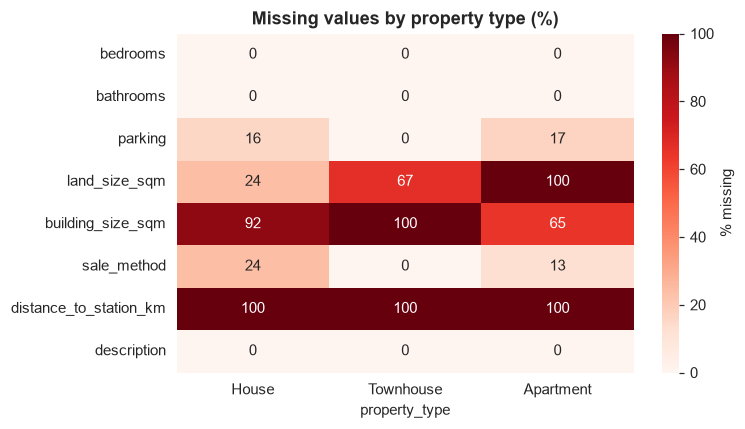

In [5]:
# Missing information – how complete is each field, by property type?
cols = ['bedrooms', 'bathrooms', 'parking', 'land_size_sqm', 'building_size_sqm',
        'sale_method', 'distance_to_station_km', 'description']
tmp = df[cols].copy()
tmp['sale_method'] = tmp['sale_method'].where(tmp['sale_method'] != 'Unknown')
missing = tmp.isna().groupby(df['property_type']).mean().T * 100
missing = missing.reindex(columns=[t for t in PROPERTY_TYPES if t in missing.columns])
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(missing, annot=True, fmt='.0f', cmap='Reds', vmin=0, vmax=100, ax=ax, cbar_kws={'label': '% missing'})
ax.set_title('Missing values by property type (%)', fontweight='bold')
plt.tight_layout(); plt.savefig('plots/plot_missing.png', dpi=120, bbox_inches='tight'); plt.show()

### Data quality, challenges, bias and limitations

**Quality.** The final dataset has 102 real sold properties (Parramatta 36, Chatswood 32, Bondi 34), sold between August 2025 and September 2026. Every row comes from a sold listing on domain.com.au and includes its URL so it can be checked. The checks at the start of Part 1 confirmed there are no duplicate listings, no missing prices or dates, and at least 30 properties per suburb. During cleaning I found and fixed some data-entry problems, recorded in the `notes` column:
- **Floor areas removed:** 4 apartments had impossible values (1,270–12,280 m²), so I removed them.
- **Land sizes removed:** 3 apartments listed the whole building's strata land, which the apartment does not own.
- **Land sizes added:** 2 house land sizes were taken from the description text.

**Challenges.** Floor area is rarely listed, especially for houses. Some descriptions are agency boilerplate text (13 Ray White listings) rather than a real description of the property. Houses were much harder to find than apartments, especially in Parramatta (only 5 houses) and Bondi (9 houses).

**Missing information (see heatmap).**
- **Building size:** missing for 92% of houses and 65% of apartments.
- **Land size:** not applicable to apartments (strata), which is different from being missing. Land size is missing for 6 houses (24%).
- **Parking and sale method:** missing for 13–24% of properties.
- **Distance to station:** not collected, so it was left out of the models.

**Bias.**
- Listings with the price withheld were skipped (the exact number was not recorded). These are often expensive or unusual sales, so the top of the market is probably under-represented.
- All data comes from one website.
- Most sales are from April–September 2026. The older sales are mostly Bondi and Chatswood houses, so time and location are mixed together.
- Listings were found with a search assistant rather than sampled at random, so the dataset may not be fully representative. Each row was checked against its listing page.
- Apartments make up 70% of the data, so house predictions rest on few examples.

**Limitations.** The data has no information on condition, renovations, views, exact street position or distance to the beach. That matters most for Bondi houses. With about 100 sales across three very different markets, results may not generalise to other suburbs or time periods.

---
## Part 2 – Data Understanding and Feature Engineering
### 2.1 Distribution of sale prices

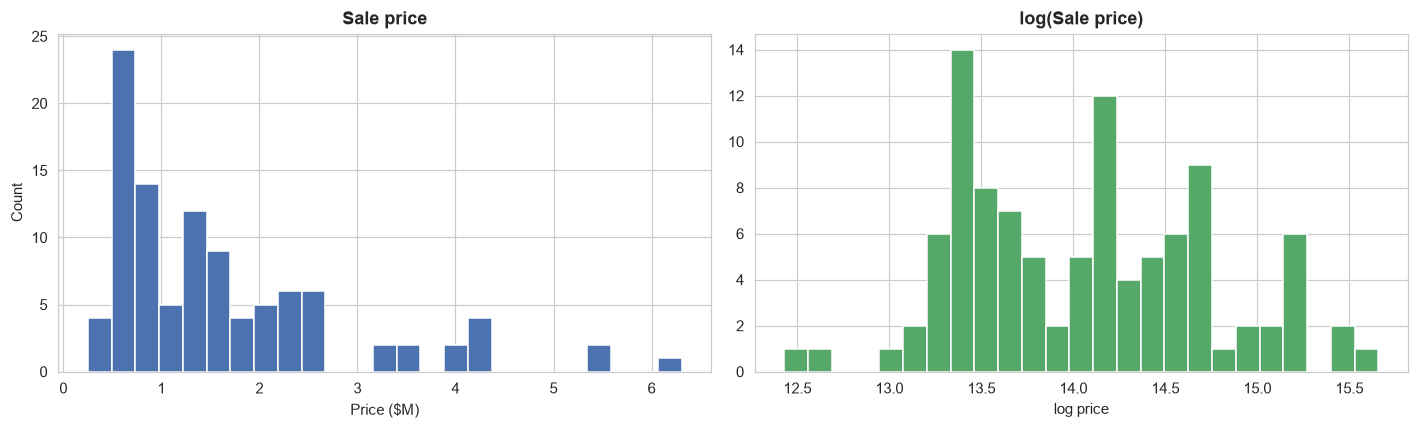

Skewness – price: 1.64   log price: 0.25


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df['sold_price'] / 1e6, bins=25, color='#4C72B0', edgecolor='white')
axes[0].set_title('Sale price', fontweight='bold'); axes[0].set_xlabel('Price ($M)'); axes[0].set_ylabel('Count')
axes[1].hist(np.log(df['sold_price']), bins=25, color='#55A868', edgecolor='white')
axes[1].set_title('log(Sale price)', fontweight='bold'); axes[1].set_xlabel('log price')
plt.tight_layout(); plt.savefig('plots/plot_price_dist.png', dpi=120, bbox_inches='tight'); plt.show()
print(f"Skewness – price: {df['sold_price'].skew():.2f}   log price: {np.log(df['sold_price']).skew():.2f}")

### 2.2 Differences between suburbs and property types

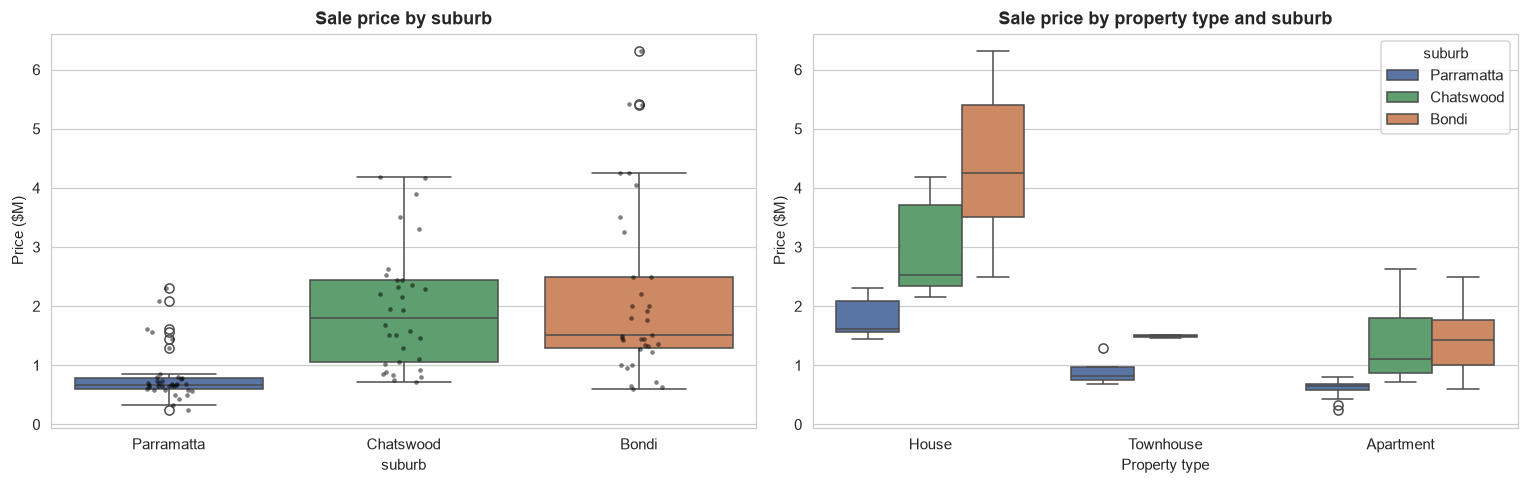

Median price ($) by suburb and type (count in brackets):
property_type       Apartment           House      Townhouse
suburb                                                      
Parramatta       650,000 (27)   1,610,000 (5)    815,000 (4)
Chatswood      1,100,000 (19)  2,530,000 (11)  1,490,000 (2)
Bondi          1,425,000 (25)   4,250,000 (9)          - (0)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(data=df, x='suburb', y=df['sold_price'] / 1e6, order=SUBURBS, palette=COLORS, ax=axes[0])
sns.stripplot(data=df, x='suburb', y=df['sold_price'] / 1e6, order=SUBURBS, color='black', size=3, alpha=0.5, ax=axes[0])
axes[0].set_ylabel('Price ($M)'); axes[0].set_title('Sale price by suburb', fontweight='bold')
types_present = [t for t in PROPERTY_TYPES if t in df['property_type'].unique()]
sns.boxplot(data=df, x='property_type', y=df['sold_price'] / 1e6, hue='suburb', order=types_present,
            hue_order=SUBURBS, palette=COLORS, ax=axes[1])
axes[1].set_ylabel('Price ($M)'); axes[1].set_xlabel('Property type')
axes[1].set_title('Sale price by property type and suburb', fontweight='bold')
plt.tight_layout(); plt.savefig('plots/plot_price_suburb_type.png', dpi=120, bbox_inches='tight'); plt.show()

print('Median price ($) by suburb and type (count in brackets):')
med = df.pivot_table(index='suburb', columns='property_type', values='sold_price', aggfunc='median').reindex(SUBURBS)
cnt = df.pivot_table(index='suburb', columns='property_type', values='sold_price', aggfunc='count').reindex(SUBURBS)
print((med.round(-3).map(lambda v: f'{v:,.0f}' if pd.notna(v) else '-') + ' (' + cnt.fillna(0).astype(int).astype(str) + ')').to_string())

### 2.3 Trends over time

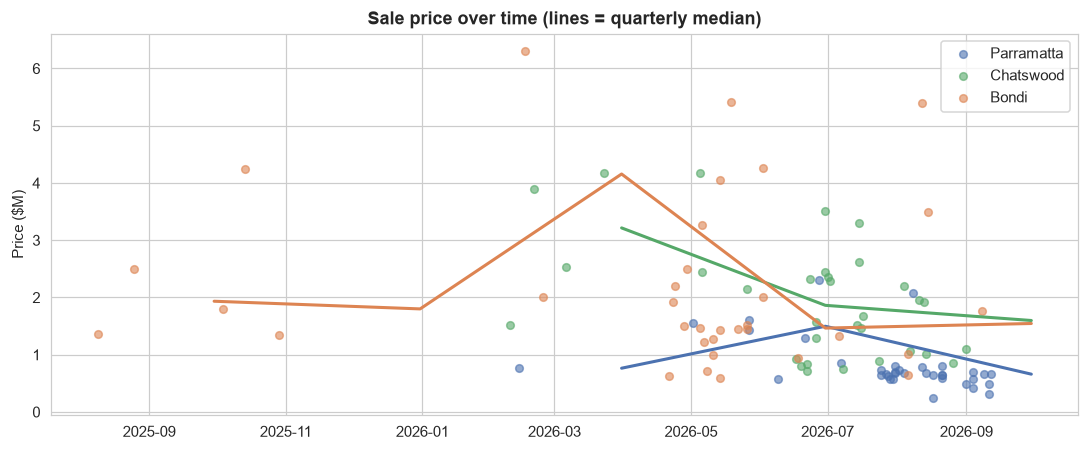

Median price by quarter ($):
suburb  Parramatta  Chatswood      Bondi
quarter                                 
2025Q3           -          -  1,934,000
2025Q4           -          -  1,800,000
2026Q1     764,000  3,215,000  4,156,500
2026Q2   1,496,944  1,862,500  1,465,000
2026Q3     660,000  1,597,500  1,545,000

Number of sales by quarter:
suburb   Parramatta  Chatswood  Bondi
quarter                              
2025Q3            0          0      2
2025Q4            0          0      3
2026Q1            1          4      2
2026Q2            6         12     21
2026Q3           29         16      6


In [8]:
fig, ax = plt.subplots(figsize=(10, 4.2))
for s in SUBURBS:
    g = df[df['suburb'] == s].sort_values('sold_date')
    ax.scatter(g['sold_date'], g['sold_price'] / 1e6, color=COLORS[s], alpha=0.6, s=25, label=s)
    q = g.set_index('sold_date')['sold_price'].resample('QE').median() / 1e6
    ax.plot(q.index, q.values, color=COLORS[s], lw=2)
ax.set_ylabel('Price ($M)'); ax.set_title('Sale price over time (lines = quarterly median)', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.savefig('plots/plot_price_time.png', dpi=120, bbox_inches='tight'); plt.show()

df['quarter'] = df['sold_date'].dt.to_period('Q').astype(str)
print('Median price by quarter ($):')
print(df.pivot_table(index='quarter', columns='suburb', values='sold_price', aggfunc='median')[SUBURBS]
      .map(lambda v: f'{v:,.0f}' if pd.notna(v) else '-').to_string())
print('\nNumber of sales by quarter:')
print(pd.crosstab(df['quarter'], df['suburb'])[SUBURBS].to_string())

### 2.4 Relationships between features and price

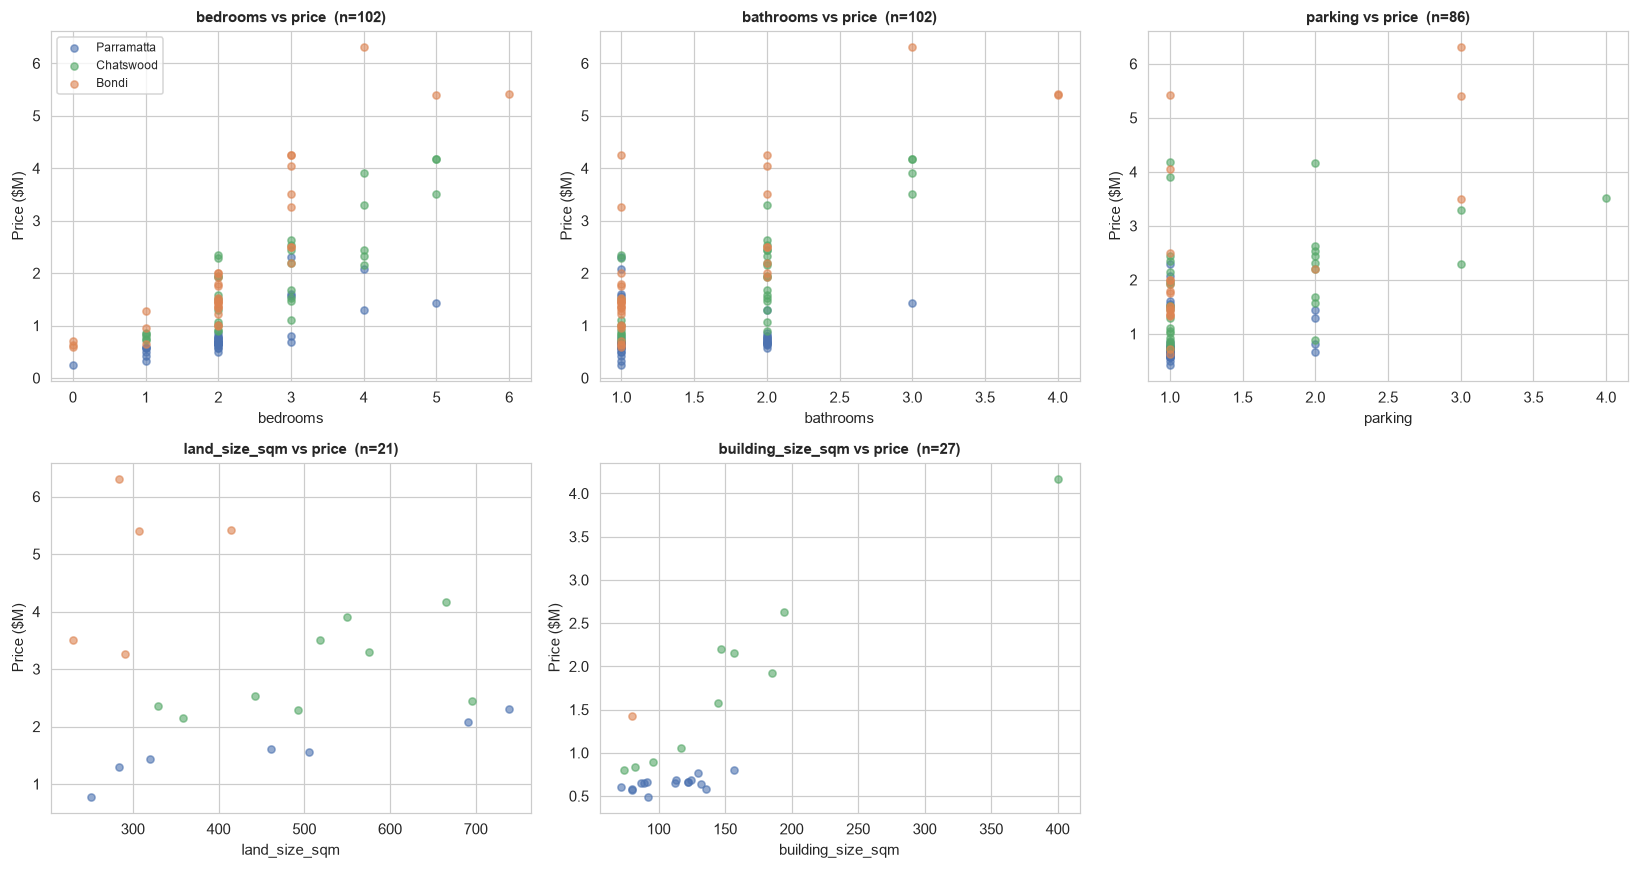

In [9]:
num_vars = ['bedrooms', 'bathrooms', 'parking', 'land_size_sqm', 'building_size_sqm', 'distance_to_station_km']
num_vars = [c for c in num_vars if df[c].notna().sum() >= 10]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.ravel(), num_vars):
    for s in SUBURBS:
        g = df[df['suburb'] == s]
        ax.scatter(g[c], g['sold_price'] / 1e6, color=COLORS[s], alpha=0.6, s=22, label=s)
    ax.set_xlabel(c); ax.set_ylabel('Price ($M)')
    ax.set_title(f'{c} vs price  (n={df[c].notna().sum()})', fontweight='bold', fontsize=10)
for ax in axes.ravel()[len(num_vars):]:
    ax.axis('off')
axes[0, 0].legend(fontsize=8)
plt.tight_layout(); plt.savefig('plots/plot_features_vs_price.png', dpi=120, bbox_inches='tight'); plt.show()

### 2.5 Unusual observations and outliers

In [10]:
# Flag outliers with the IQR rule on log price *within each suburb and property type*
def iqr_flag(g):
    lp = np.log(g['sold_price'])
    q1, q3 = lp.quantile([0.25, 0.75])
    return (lp < q1 - 1.5 * (q3 - q1)) | (lp > q3 + 1.5 * (q3 - q1))
df['outlier'] = df.groupby(['suburb', 'property_type'], group_keys=False).apply(iqr_flag).astype(bool)
show = ['property_id', 'suburb', 'property_type', 'bedrooms', 'bathrooms', 'land_size_sqm',
        'building_size_sqm', 'sold_price', 'notes']
print(f"{df['outlier'].sum()} unusual sales (IQR rule within suburb × type):")
print(df.loc[df['outlier'], show].to_string(index=False))

3 unusual sales (IQR rule within suburb × type):
property_id     suburb property_type  bedrooms  bathrooms  land_size_sqm  building_size_sqm  sold_price                                                 notes
       P010 Parramatta     Apartment         1          1            NaN                NaN      320000 Very low price - small investment/serviced apartment.
       P011 Parramatta     Apartment         1          1            NaN                NaN      425000               Description is agency boilerplate text.
       P028 Parramatta     Apartment         0          1            NaN                NaN      250000 Very low price - small investment/serviced apartment.


**What I found from the EDA**

**Price distribution:** Most properties sold for under $2M, but a few expensive houses in Bondi and Chatswood sold for $4–6M, so the prices are skewed to the right (skewness 1.64). Taking the log of the price made the distribution much more even (skewness 0.25), so I used log(price) as the target for my models. This stops the few very expensive houses from having too much effect.

**Suburbs:** Parramatta is the cheapest suburb (median about $674k), mainly because most sales there are apartments. Chatswood has the highest median ($1.80M). Bondi's median ($1.51M) is a bit lower because most of its sales are apartments, but Bondi has the most expensive properties overall (up to $6.3M) and the biggest price range.

**Houses vs apartments:** Houses cost a lot more than apartments in every suburb: about 2.5 times more in Parramatta, 2.3 times in Chatswood and 3 times in Bondi. Location matters too: a Bondi apartment costs about the same as a Parramatta house.

**Other features:** Price goes up with more bedrooms, bathrooms and parking spaces. Land size was surprising. Bondi houses have small blocks but the highest prices, so land size only shows a clear pattern when you compare houses within the same suburb.

**Over time:** Most of my sales are from April to September 2026. The quarterly prices jump up and down, but this is because different types of properties sold in each quarter, not because the market changed. The time period is too short to see a real trend.

**Outliers:** Three cheap Parramatta apartments were flagged as outliers ($250k, $320k and $425k). I checked them and they are real sales of small investment apartments, not mistakes, so I kept them. The expensive Bondi houses were not flagged because those prices are normal for Bondi houses. The actual data-entry mistakes (like impossible floor areas) were already fixed during cleaning.

### 2.6 Expected strongest predictors (written *before* feature engineering)

Before doing any feature engineering, these are the three variables I think will affect house prices the most:

1. **Suburb (location).** The three suburbs are very different: Bondi is near the beach, Chatswood is on the North Shore with good schools, and Parramatta is further from the city. So I expect the same property to sell for very different prices in each suburb.
2. **Property type (house, townhouse or apartment).** In Sydney, most of a property's value is the land. A house comes with its own land, but an apartment only shares the land with the whole building. So I expect houses to cost much more than apartments.
3. **Land size.** For houses, a bigger block of land should mean a higher price, because land is scarce and can be redeveloped.

I think bedrooms, bathrooms and floor size will matter too, but less than these three. I don't expect sale date to matter much, because all the sales are from a short period.

In [11]:
# Evidence from the EDA (no engineered features, no models): how strongly is each raw variable
# associated with log(price)?
lp = np.log(df['sold_price'])
def eta_sq(cat):                        # share of variance in log price explained by group means
    g = lp.groupby(df[cat])
    return float(((g.transform('mean') - lp.mean()) ** 2).sum() / ((lp - lp.mean()) ** 2).sum())

rows = []
for c in ['suburb', 'property_type', 'sale_method']:
    rows.append({'variable': c, 'kind': 'categorical', 'association': eta_sq(c), 'measure': 'eta² (variance explained)', 'n': df[c].notna().sum()})
for c in ['bedrooms', 'bathrooms', 'parking', 'land_size_sqm', 'building_size_sqm', 'distance_to_station_km']:
    ok = df[c].notna()
    if ok.sum() >= 10:
        rho = df.loc[ok, c].corr(lp[ok], method='spearman')
        rows.append({'variable': c, 'kind': 'numeric', 'association': rho ** 2, 'measure': f'Spearman ρ² (ρ = {rho:+.2f})', 'n': int(ok.sum())})
ok = df['sold_date'].notna()
rho = df.loc[ok, 'sold_date'].map(pd.Timestamp.toordinal).corr(lp[ok], method='spearman')
rows.append({'variable': 'sold_date', 'kind': 'numeric', 'association': rho ** 2, 'measure': f'Spearman ρ² (ρ = {rho:+.2f})', 'n': int(ok.sum())})
assoc = pd.DataFrame(rows).sort_values('association', ascending=False).reset_index(drop=True)
assoc.index += 1
print('Raw variables ranked by association with log(price):')
print(assoc.round(3).to_string())

# Land size matters only where land exists: look inside houses
houses = df[(df['property_type'] == 'House') & df['land_size_sqm'].notna()]
if len(houses) >= 8:
    print(f"\nWithin houses only (n={len(houses)}): Spearman ρ(land size, log price) = "
          f"{houses['land_size_sqm'].corr(np.log(houses['sold_price']), method='spearman'):+.2f}")
    for s in SUBURBS:
        h = houses[houses['suburb'] == s]
        if len(h) >= 5:
            print(f"   {s:10s} (n={len(h)}): ρ = {h['land_size_sqm'].corr(np.log(h['sold_price']), method='spearman'):+.2f}")

Raw variables ranked by association with log(price):
            variable         kind  association                    measure    n
1           bedrooms      numeric        0.559    Spearman ρ² (ρ = +0.75)  102
2      property_type  categorical        0.511  eta² (variance explained)  102
3             suburb  categorical        0.376  eta² (variance explained)  102
4  building_size_sqm      numeric        0.322    Spearman ρ² (ρ = +0.57)   27
5          sold_date      numeric        0.269    Spearman ρ² (ρ = -0.52)  102
6            parking      numeric        0.204    Spearman ρ² (ρ = +0.45)   86
7          bathrooms      numeric        0.187    Spearman ρ² (ρ = +0.43)  102
8        sale_method  categorical        0.130  eta² (variance explained)  102
9      land_size_sqm      numeric        0.003    Spearman ρ² (ρ = +0.05)   21

Within houses only (n=19): Spearman ρ(land size, log price) = -0.20
   Parramatta (n=5): ρ = +0.90
   Chatswood  (n=9): ρ = +0.60
   Bondi      (n=5): ρ = +

### 2.7 Feature engineering

Each engineered feature is linked to my expectations above (code in `housing_features.py`, shared with the app):

| Engineered feature | Why | Linked to |
|---|---|---|
| **log(price)** as the target | prices are right-skewed; errors become roughly proportional, and suburb/type act as multipliers | suburb, type |
| `is_strata` | apartments (and strata townhouses) have no land of their own – separates "no land" from "land not recorded" | property type, land |
| `log_land` (0 for strata) and `land_missing` flag | diminishing returns of extra land; keeps houses with unknown land size in the data | land size |
| `building_missing` flag (+ median imputation in the model) | floor area is often not listed; the flag stops imputed values looking like real ones | size |
| `total_rooms`, `bath_per_bed` | overall size and quality/luxury proxy when floor area is missing | size |
| `months_since_2023` | captures market movement over the collection window | time |
| `is_auction` | auction sales often happen in stronger markets / for more desirable homes | – |
| description keyword flags (`kw_renovated`, `kw_original`, `kw_views`, `kw_water`, `kw_pool`, `kw_garden`, `kw_station`, `kw_school`, `kw_develop`) and `desc_words` | text from the agent description adds information that isn't in the numeric fields (condition, views, development potential) | within-suburb variation |

Suburb and property type are **one-hot encoded** inside the model pipeline (no order between them, unlike my earlier label encoding).

In [12]:
data = engineer(df)
CAT, NUM = feature_lists(data)
X = data[CAT + NUM]
y = data['sold_price']
print(f'Model features: {len(CAT)} categorical + {len(NUM)} numeric')
print('Categorical:', CAT)
print('Numeric:', NUM)

kw = data[list(KEYWORDS)].mean().sort_values(ascending=False) * 100
print('\n% of listings mentioning each keyword group:')
print(kw.round(1).to_string())

Model features: 2 categorical + 22 numeric
Categorical: ['suburb', 'property_type']
Numeric: ['bedrooms', 'bathrooms', 'parking', 'log_land', 'building_size_sqm', 'is_strata', 'land_missing', 'building_missing', 'total_rooms', 'bath_per_bed', 'months_since_2023', 'is_auction', 'desc_words', 'kw_renovated', 'kw_original', 'kw_views', 'kw_water', 'kw_pool', 'kw_garden', 'kw_station', 'kw_school', 'kw_develop']

% of listings mentioning each keyword group:
kw_water        7.8
kw_renovated    5.9
kw_views        4.9
kw_develop      3.9
kw_garden       2.0
kw_original     1.0
kw_pool         0.0
kw_station      0.0
kw_school       0.0


In [13]:
# Do the engineered features behave as expected? (still no models)
lp = np.log(data['sold_price'])
check = []
for f in ['is_strata', 'land_missing', 'building_missing', 'is_auction'] + list(KEYWORDS):
    if data[f].nunique() == 2 and data[f].sum() >= 3:
        diff = np.exp(lp[data[f] == 1].mean() - lp[data[f] == 0].mean()) - 1
        check.append({'feature': f, 'n with feature': int(data[f].sum()), 'price difference (geo-mean)': f'{diff:+.0%}'})
for f in ['log_land', 'total_rooms', 'bath_per_bed', 'months_since_2023', 'desc_words']:
    check.append({'feature': f, 'n with feature': int(data[f].notna().sum()),
                  'price difference (geo-mean)': f"Spearman ρ = {data[f].corr(lp, method='spearman'):+.2f}"})
print(pd.DataFrame(check).to_string(index=False))

          feature  n with feature price difference (geo-mean)
        is_strata              75                        -65%
     land_missing               6                       +189%
 building_missing              75                        +56%
       is_auction              24                        +32%
     kw_renovated               6                        +30%
         kw_views               5                        +44%
         kw_water               8                       +132%
       kw_develop               4                        -11%
         log_land             102          Spearman ρ = +0.51
      total_rooms             102          Spearman ρ = +0.67
     bath_per_bed             102          Spearman ρ = -0.38
months_since_2023             102          Spearman ρ = -0.52
       desc_words             102          Spearman ρ = +0.24


### 2.8 Reflection – do the EDA and feature engineering agree with my initial expectation?

**Suburb:** Suburb was important (it explains about 38% of the variation in log price), but it came 3rd, not 1st as I expected. Chatswood had the highest median price, which surprised me because I thought Bondi would be the most expensive. Bondi does have the most expensive properties, but most of its sales are apartments, which brings its median down.

**Property type:** This matched my expectation. Property type explains about 51% of the variation and came 2nd. Apartments (strata properties) sold for about 65% less than houses on average, and houses were more expensive than apartments in every suburb.

**Land size:** This did not match my expectation. On its own, land size had almost no relationship with price (only 21 properties had a land size). Within each suburb, bigger blocks did sell for more (e.g. ρ = +0.90 in Parramatta and +0.60 in Chatswood), but Bondi houses have small blocks and the highest prices, so the pattern disappears when all suburbs are mixed together. Because land only matters for houses, I didn't use raw land size alone. I created `is_strata` (to separate apartments with no land from houses where land wasn't recorded), `log_land` (0 for apartments) and `land_missing`. The engineered `log_land` has a much stronger relationship with price (ρ = +0.51).

**What surprised me:**
- **Bedrooms** was the strongest single variable (ρ = +0.75), even stronger than suburb. This is probably because bedrooms also shows property type: houses usually have more bedrooms than apartments. Because of this, I added `total_rooms`, which also has a strong link to price (ρ = +0.67).
- **Sale date** had a fairly strong negative link to price (ρ = −0.52). I don't think prices actually fell. My older sales are mostly expensive Bondi and Chatswood houses, and the newer ones are mostly cheaper Parramatta apartments, so this result needs to be interpreted carefully.

- Listings mentioning **water/ocean** sold for much more (+132%), but only 8 listings had this keyword.

**Conclusion:** My expectations mostly agree with the EDA. Two of my three variables (property type and suburb) were in the top 3. Land size was the main difference: it only matters within houses and within a suburb, so I engineered it together with strata status instead of using it as a single raw variable. The EDA also showed that the number of rooms matters more than I expected, so I added room-based features.

---
## Part 3 – Model Development and Evaluation

### Model choice and expectations (written before training)
| Model | Approach | Why selected | Strengths | Weaknesses |
|---|---|---|---|---|
| **Ridge regression** (on log price) | linear, regularised | interpretable baseline; on log price the coefficients are % effects (e.g. "Bondi adds x%") | stable with ~100 rows, few parameters | cannot capture interactions (suburb × type) unless added by hand |
| **Random Forest** | bagging of deep trees | captures non-linear effects and interactions automatically, robust to outliers and missing-value flags | low variance through averaging, little tuning | can't extrapolate beyond seen prices (e.g. rare luxury sales); needs data per segment |
| **Gradient Boosting** | boosting of shallow trees | often the strongest method on tabular data | reduces bias step by step, models interactions | easier to overfit a small, noisy dataset; more hyperparameters |

**Expectation:** with only ~100 properties and strong suburb × type interactions, I expect **Random Forest to perform best**, Gradient Boosting to be close but less stable, and Ridge to have the highest error.

**Evaluation:** all models predict log(price) and are converted back to dollars. Hyperparameters are tuned with an inner 5-fold grid search and performance is measured with an **outer 5-fold cross-validation** (nested CV), so the reported scores are not biased by the tuning. Metrics: **MAE** (average dollar error – easy for clients), **RMSE** (penalises large misses), **MAPE** (error as % of price – fair across cheap and expensive suburbs) and **R²**.

In [14]:
def make_pre(scale):
    num_steps = [('impute', SimpleImputer(strategy='median'))] + ([('scale', StandardScaler())] if scale else [])
    return ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore'), CAT),
        ('num', Pipeline(num_steps), NUM),
    ])

def log_target(reg):
    return TransformedTargetRegressor(regressor=reg, func=np.log, inverse_func=np.exp)

models = {
    'Ridge': (Pipeline([('pre', make_pre(True)), ('model', log_target(Ridge()))]),
              {'model__regressor__alpha': [0.1, 1, 3, 10, 30]}),
    'Random Forest': (Pipeline([('pre', make_pre(False)),
                                ('model', log_target(RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE)))]),
                      {'model__regressor__max_depth': [4, 8, None],
                       'model__regressor__min_samples_leaf': [1, 3, 5],
                       'model__regressor__max_features': [0.5, 1.0]}),
    'Gradient Boosting': (Pipeline([('pre', make_pre(False)),
                                    ('model', log_target(GradientBoostingRegressor(random_state=RANDOM_STATE)))]),
                          {'model__regressor__n_estimators': [100, 300],
                           'model__regressor__learning_rate': [0.03, 0.1],
                           'model__regressor__max_depth': [2, 3],
                           'model__regressor__subsample': [0.8, 1.0]}),
}

def mape(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred) / y_true) * 100

scoring = {'MAE': 'neg_mean_absolute_error', 'RMSE': 'neg_root_mean_squared_error',
           'MAPE': 'neg_mean_absolute_percentage_error', 'R2': 'r2'}
inner = KFold(5, shuffle=True, random_state=RANDOM_STATE)
outer = KFold(5, shuffle=True, random_state=RANDOM_STATE + 1)

In [15]:
cv_results, searches = {}, {}
for name, (pipe, grid) in models.items():
    search = GridSearchCV(pipe, grid, cv=inner, scoring='neg_mean_absolute_error', n_jobs=-1)
    res = cross_validate(search, X, y, cv=outer, scoring=scoring, return_train_score=True, n_jobs=-1)
    cv_results[name] = res
    searches[name] = search.fit(X, y)          # final tuned model on all data
    print(f'{name:18s} best params (all data): {searches[name].best_params_}')

rows = []
for name, res in cv_results.items():
    r = {'Model': name}
    for m in ['MAE', 'RMSE', 'MAPE', 'R2']:
        sign = 1 if m == 'R2' else -1
        mult = 100 if m == 'MAPE' else 1
        r[f'CV {m}'] = sign * res[f'test_{m}'].mean() * mult
        r[f'CV {m} sd'] = res[f'test_{m}'].std() * mult
        r[f'Train {m}'] = sign * res[f'train_{m}'].mean() * mult
    rows.append(r)
summary = pd.DataFrame(rows).set_index('Model')
pd.options.display.float_format = '{:,.3f}'.format
show = summary[['CV MAE', 'CV MAE sd', 'Train MAE', 'CV RMSE', 'CV MAPE', 'Train MAPE', 'CV R2', 'CV R2 sd', 'Train R2']]
print('\nNested 5-fold CV results (MAE/RMSE in $, MAPE in %):')
print(show.to_string(formatters={c: '{:,.0f}'.format for c in ['CV MAE', 'CV MAE sd', 'Train MAE', 'CV RMSE']}))
best_name = summary['CV MAE'].idxmin()
pd.reset_option('display.float_format')
print(f'\nLowest CV MAE: {best_name}')

Ridge              best params (all data): {'model__regressor__alpha': 30}


Random Forest      best params (all data): {'model__regressor__max_depth': 8, 'model__regressor__max_features': 0.5, 'model__regressor__min_samples_leaf': 1}


Gradient Boosting  best params (all data): {'model__regressor__learning_rate': 0.03, 'model__regressor__max_depth': 2, 'model__regressor__n_estimators': 300, 'model__regressor__subsample': 0.8}

Nested 5-fold CV results (MAE/RMSE in $, MAPE in %):
                   CV MAE CV MAE sd Train MAE CV RMSE  CV MAPE  Train MAPE  CV R2  CV R2 sd  Train R2
Model                                                                                                
Ridge             446,603   119,835   288,767 778,094   24.623      17.833  0.352     0.706     0.881
Random Forest     372,667   129,292   204,697 559,854   21.754      12.278  0.763     0.100     0.934
Gradient Boosting 321,364    98,945   122,591 464,658   19.842       8.069  0.828     0.079     0.978

Lowest CV MAE: Gradient Boosting


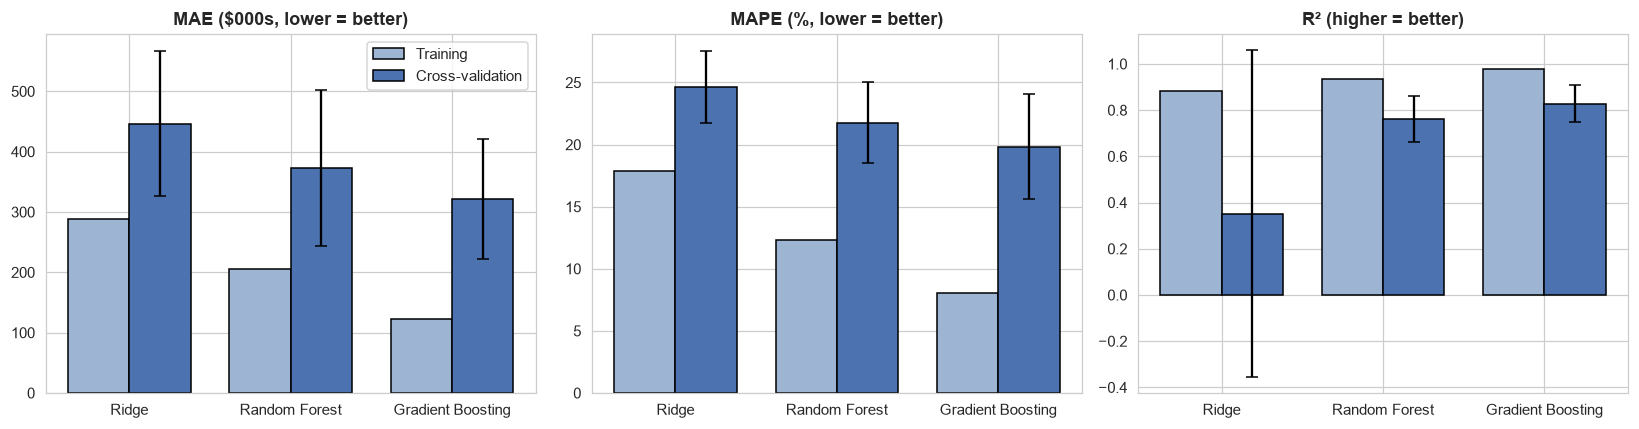

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
names = list(summary.index); x = np.arange(len(names)); w = 0.38
for ax, m, title in [(axes[0], 'MAE', 'MAE ($000s, lower = better)'), (axes[1], 'MAPE', 'MAPE (%, lower = better)'),
                     (axes[2], 'R2', 'R² (higher = better)')]:
    k = 1000 if m == 'MAE' else 1
    ax.bar(x - w/2, summary[f'Train {m}'] / k, w, label='Training', color='#9DB4D3', edgecolor='black')
    ax.bar(x + w/2, summary[f'CV {m}'] / k, w, yerr=summary[f'CV {m} sd'] / k, capsize=4,
           label='Cross-validation', color='#4C72B0', edgecolor='black')
    ax.set_xticks(x); ax.set_xticklabels(names); ax.set_title(title, fontweight='bold')
axes[0].legend()
plt.tight_layout(); plt.savefig('plots/plot_model_comparison.png', dpi=120, bbox_inches='tight'); plt.show()

### Model complexity – underfitting vs overfitting

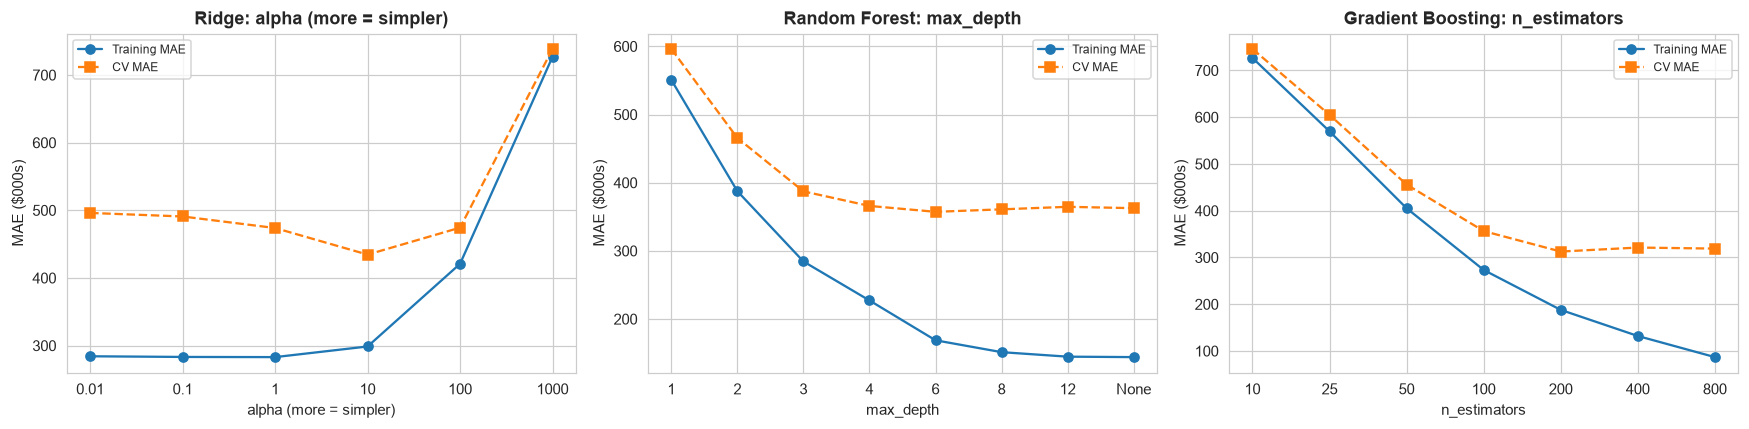

alpha (more = simpler)  Train MAE  CV MAE
                  0.01     284230  496125
                   0.1     283239  490902
                     1     282995  473824
                    10     298712  434523
                   100     420917  474382
                  1000     726993  738585 

max_depth  Train MAE  CV MAE
        1     550837  596230
        2     387532  465583
        3     284445  387297
        4     227247  365915
        6     168828  357282
        8     151409  360911
       12     144808  364624
     None     144155  362627 

n_estimators  Train MAE  CV MAE
          10     726678  745936
          25     569651  604909
          50     405214  456000
         100     273256  356401
         200     187897  312637
         400     132069  321186
         800      86910  318961 



In [17]:
def complexity_curve(ax, name, param, values, label, log_x=False):
    pipe = searches[name].best_estimator_
    tr, va = validation_curve(pipe, X, y, param_name=param, param_range=values, cv=outer,
                              scoring='neg_mean_absolute_error', n_jobs=-1)
    xs = [str(v) for v in values]
    ax.plot(xs, -tr.mean(1) / 1000, 'o-', label='Training MAE')
    ax.plot(xs, -va.mean(1) / 1000, 's--', label='CV MAE')
    ax.set_title(f'{name}: {label}', fontweight='bold'); ax.set_xlabel(label); ax.set_ylabel('MAE ($000s)')
    ax.legend(fontsize=8)
    return pd.DataFrame({label: [str(v) for v in values], 'Train MAE': (-tr.mean(1)).round(0).astype(int), 'CV MAE': (-va.mean(1)).round(0).astype(int)})

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
c1 = complexity_curve(axes[0], 'Ridge', 'model__regressor__alpha', [0.01, 0.1, 1, 10, 100, 1000], 'alpha (more = simpler)')
c2 = complexity_curve(axes[1], 'Random Forest', 'model__regressor__max_depth', [1, 2, 3, 4, 6, 8, 12, None], 'max_depth')
c3 = complexity_curve(axes[2], 'Gradient Boosting', 'model__regressor__n_estimators', [10, 25, 50, 100, 200, 400, 800], 'n_estimators')
plt.tight_layout(); plt.savefig('plots/plot_complexity.png', dpi=120, bbox_inches='tight'); plt.show()
for c in (c1, c2, c3):
    print(c.to_string(index=False), '\n')

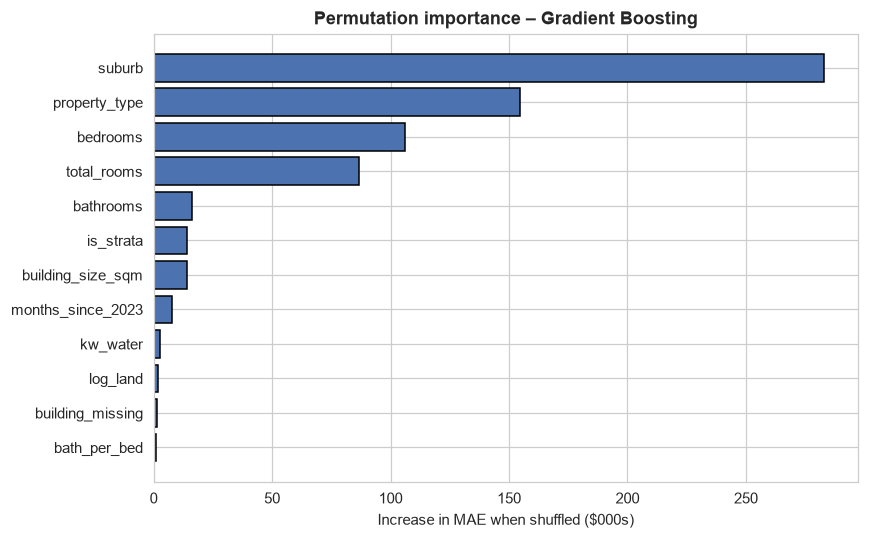

suburb               283.1
property_type        154.7
bedrooms             105.9
total_rooms           86.7
bathrooms             16.2
is_strata             13.9
building_size_sqm     13.9
months_since_2023      7.8
kw_water               2.6
log_land               2.0


In [18]:
# Which features does the best model rely on? (permutation importance, 5-fold, on held-out folds)
imp_rows = []
for tr_idx, te_idx in outer.split(X):
    m = clone(searches[best_name].best_estimator_).fit(X.iloc[tr_idx], y.iloc[tr_idx])
    pi = permutation_importance(m, X.iloc[te_idx], y.iloc[te_idx], scoring='neg_mean_absolute_error',
                                n_repeats=10, random_state=RANDOM_STATE)
    imp_rows.append(pd.Series(pi.importances_mean, index=X.columns))
imp = pd.concat(imp_rows, axis=1).mean(1).sort_values(ascending=False)
top = imp.head(12)[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top.index, top.values / 1000, color='#4C72B0', edgecolor='black')
ax.set_xlabel('Increase in MAE when shuffled ($000s)')
ax.set_title(f'Permutation importance – {best_name}', fontweight='bold')
plt.tight_layout(); plt.savefig('plots/plot_feature_importance.png', dpi=120, bbox_inches='tight'); plt.show()
print((imp.head(10) / 1000).round(1).to_string())

In [19]:
# Ridge coefficients: % effect on price (interpretable view)
ridge = searches['Ridge'].best_estimator_
names_out = ridge.named_steps['pre'].get_feature_names_out()
coef = pd.Series(ridge.named_steps['model'].regressor_.coef_, index=names_out)
pct = (np.exp(coef) - 1) * 100
print('Ridge – % change in price (categorical: vs average; numeric: per 1 standard deviation):')
print(pct.reindex(pct.abs().sort_values(ascending=False).index).head(12).round(1).to_string())

Ridge – % change in price (categorical: vs average; numeric: per 1 standard deviation):
cat__suburb_Parramatta     -18.2
cat__suburb_Bondi           12.1
num__bedrooms               11.0
num__total_rooms            10.3
cat__suburb_Chatswood        9.1
num__months_since_2023      -8.6
num__kw_water                7.4
num__bathrooms               7.2
num__is_strata              -6.9
num__bath_per_bed           -6.5
cat__property_type_House     5.6
num__log_land                5.4


### Critical analysis, expectations revisited and recommendation

**Comparing the models:**

| Model | CV MAE | CV MAPE | CV R² |
|---|---|---|---|
| Ridge | $446,603 (± $119,835) | 24.6% | 0.35 (± 0.71) |
| Random Forest | $372,588 (± $128,917) | 21.8% | 0.76 (± 0.10) |
| Gradient Boosting | $321,364 (± $98,945) | 19.8% | 0.83 (± 0.08) |

Gradient Boosting was the best on every metric. Its predictions are off by about $321k (around 20%) on average, and it explains about 83% of the variation in price. It also had the smallest spread across the 5 folds, so it was the most stable. Ridge was the weakest, and its R² changed a lot between folds (± 0.71). This means it did very badly on at least one fold, probably one with several expensive houses that a straight-line model can't handle.

**Underfitting and overfitting:**
- **Ridge underfits (high bias).** Even its training error is high ($289k). A linear model can't capture interactions like "a house in Bondi is worth much more than a house plus a Bondi premium". The complexity curve shows the best alpha is around 10. Very large alpha (1000) makes it too simple (CV MAE $739k), and very small alpha overfits slightly.
- **Random Forest overfits (high variance).** Training MAE is $205k but CV MAE is $373k. The complexity curve shows CV error stops improving after about depth 4–6 (around $360k), while training error keeps going down. Deeper trees just memorise the training data.
- **Gradient Boosting also overfits somewhat.** Training MAPE is 8% vs 20% in CV. However, its CV error is still the lowest. The curve shows CV error is best at around 200 trees ($313k) and then stops improving while training error keeps dropping, so adding more trees would only increase overfitting. The tuned settings (shallow trees of depth 2 and a small learning rate of 0.03) help control this.

**Expectations revisited:** I expected Random Forest to be the best, but Gradient Boosting won. I think this is because boosting builds many small trees, each one correcting the errors of the previous ones. With shallow trees and a small learning rate, it learned the main patterns (suburb × property type) without memorising the data as much as Random Forest's deep trees. As expected, Ridge was the weakest, because house prices in my data depend on combinations of features, not straight-line effects.

**Do the important features agree with my Part 2 expectation?** Mostly yes. For Gradient Boosting, the most important features were suburb, property type, bedrooms and total rooms. Land size had very little importance, which matches what I found in the EDA: land only matters within houses in the same suburb. Suburb came 1st in the model but only 3rd in the EDA. I think this is because the model can separate the effect of suburb from property type, while the EDA looked at each variable on its own. The Ridge coefficients tell the same story: being in Parramatta lowers the price by about 18% compared to average, and being in Bondi raises it by about 12%.

**Recommendation:** I recommend **Gradient Boosting**. It has the lowest error, the highest R² and the most stable results across folds. It is also small and fast, so it's easy to use in the Streamlit app. Its main weakness is that it is harder to explain than Ridge, so the Ridge coefficients can still be used to explain the general effects to clients. An average error of about 20% means the predictions should be used as a rough guide, not an exact valuation, especially for expensive or unusual houses.

---
## Part 4 – Investigating Prediction Failures
Out-of-fold predictions are used, so every property is predicted by a model that did **not** see it during training.

In [20]:
final_model = searches[best_name].best_estimator_
data['predicted'] = cross_val_predict(final_model, X, y, cv=outer, n_jobs=-1)
data['error'] = data['predicted'] - data['sold_price']
data['abs_error'] = data['error'].abs()
data['pct_error'] = data['abs_error'] / data['sold_price'] * 100
print(f"{best_name} out-of-fold: MAE ${data['abs_error'].mean():,.0f} | MAPE {data['pct_error'].mean():.1f}% | "
      f"R² {r2_score(data['sold_price'], data['predicted']):.3f}")

worst = data.sort_values('abs_error', ascending=False).head(5)
cols = ['property_id', 'suburb', 'address', 'property_type', 'bedrooms', 'bathrooms', 'parking',
        'land_size_sqm', 'building_size_sqm', 'sold_date', 'sale_method', 'sold_price', 'predicted',
        'error', 'pct_error', 'outlier', 'notes']
with pd.option_context('display.float_format', '{:,.0f}'.format, 'display.max_colwidth', 40):
    print(worst[cols].to_string(index=False))

Gradient Boosting out-of-fold: MAE $317,179 | MAPE 19.3% | R² 0.846
property_id    suburb               address property_type  bedrooms  bathrooms  parking  land_size_sqm  building_size_sqm  sold_date sale_method  sold_price  predicted      error  pct_error  outlier                                      notes
       B013     Bondi       2 Denham Street         House         4          3        3            284                NaN 2026-02-16     Unknown     6308000  4,434,675 -1,873,325         30    False                                       <NA>
       B014     Bondi 23 Ocean Street North         House         3          2      NaN            NaN                NaN 2025-08-25     Unknown     2500000  4,174,994  1,674,994         67    False House - land size not recorded on listing.
       B017     Bondi    14 Anglesea Street         House         6          4        1            415                NaN 2026-05-19     Auction     5416000  3,989,923 -1,426,077         26    False        

In [21]:
for rank, (_, r) in enumerate(worst.iterrows(), 1):
    direction = 'UNDER-estimated' if r['error'] < 0 else 'OVER-estimated'
    print(f"#{rank} {r['property_id']} – {r['address']}, {r['suburb']} | {r['property_type']}, "
          f"{r['bedrooms']:.0f} bed / {r['bathrooms']:.0f} bath / {r['parking']:.0f} car")
    print(f"   Actual ${r['sold_price']:,.0f} | Predicted ${r['predicted']:,.0f} | {direction} by "
          f"${abs(r['error']):,.0f} ({r['pct_error']:.1f}%)")
    seg = data[(data['suburb'] == r['suburb']) & (data['property_type'] == r['property_type'])]
    print(f"   Similar properties in data (same suburb & type): {len(seg)}, median ${seg['sold_price'].median():,.0f}")
    flags = [k.replace('kw_', '') for k in KEYWORDS if r[k] == 1]
    print(f"   Description keywords: {flags or 'none'} | IQR outlier: {r['outlier']}")
    print(f"   Description: {str(r['description'])[:300]}")
    print(f"   Listing: {r.get('listing_url', '')}\n")

#1 B013 – 2 Denham Street, Bondi | House, 4 bed / 3 bath / 3 car
   Actual $6,308,000 | Predicted $4,434,675 | UNDER-estimated by $1,873,325 (29.7%)
   Similar properties in data (same suburb & type): 9, median $4,250,000
   Description keywords: ['water'] | IQR outlier: False
   Description: Perfectly poised between Bondi and Tamarama Beaches, this remarkable new home exhibits…
   Listing: https://www.domain.com.au/2-denham-street-bondi-nsw-2026-2020549529

#2 B014 – 23 Ocean Street North, Bondi | House, 3 bed / 2 bath / nan car
   Actual $2,500,000 | Predicted $4,174,994 | OVER-estimated by $1,674,994 (67.0%)
   Similar properties in data (same suburb & type): 9, median $4,250,000
   Description keywords: none | IQR outlier: False
   Description: Imbued with character and radiating with natural light, this freestanding home elevates…
   Listing: https://www.domain.com.au/23-ocean-street-north-bondi-nsw-2026-2019805350

#3 B017 – 14 Anglesea Street, Bondi | House, 6 bed / 4 bath / 1 c

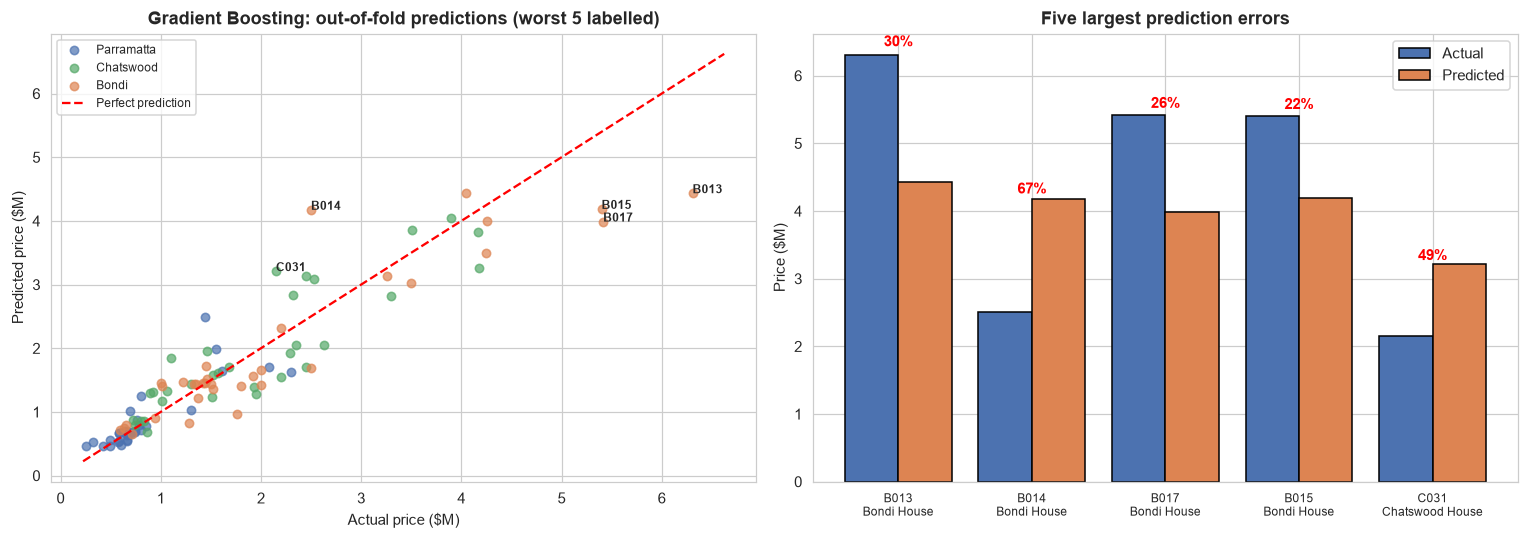

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
for s in SUBURBS:
    g = data[data['suburb'] == s]
    ax.scatter(g['sold_price'] / 1e6, g['predicted'] / 1e6, color=COLORS[s], alpha=0.7, s=30, label=s)
lim = [data[['sold_price', 'predicted']].min().min() / 1e6 * 0.9, data[['sold_price', 'predicted']].max().max() / 1e6 * 1.05]
ax.plot(lim, lim, 'r--', label='Perfect prediction')
for _, r in worst.iterrows():
    ax.annotate(r['property_id'], (r['sold_price'] / 1e6, r['predicted'] / 1e6), fontsize=8, fontweight='bold')
ax.set_xlabel('Actual price ($M)'); ax.set_ylabel('Predicted price ($M)')
ax.set_title(f'{best_name}: out-of-fold predictions (worst 5 labelled)', fontweight='bold'); ax.legend(fontsize=8)

ax = axes[1]
lab = worst['property_id'] + '\n' + worst['suburb'] + ' ' + worst['property_type']
xx = np.arange(5)
ax.bar(xx - 0.2, worst['sold_price'] / 1e6, 0.4, label='Actual', color='#4C72B0', edgecolor='black')
ax.bar(xx + 0.2, worst['predicted'] / 1e6, 0.4, label='Predicted', color='#DD8452', edgecolor='black')
for i, (_, r) in enumerate(worst.iterrows()):
    ax.text(i, max(r['sold_price'], r['predicted']) / 1e6 * 1.02, f"{r['pct_error']:.0f}%", ha='center', color='red', fontweight='bold')
ax.set_xticks(xx); ax.set_xticklabels(lab, fontsize=8); ax.set_ylabel('Price ($M)')
ax.set_title('Five largest prediction errors', fontweight='bold'); ax.legend()
plt.tight_layout(); plt.savefig('plots/plot_worst_errors.png', dpi=120, bbox_inches='tight'); plt.show()

In [23]:
# Are some types of property harder to model?
seg = data.groupby(['suburb', 'property_type']).agg(n=('sold_price', 'size'),
        median_price=('sold_price', 'median'), MAE=('abs_error', 'mean'), MAPE=('pct_error', 'mean'))
with pd.option_context('display.float_format', '{:,.1f}'.format):
    print(seg.reindex(SUBURBS, level=0).to_string())
print(f"\nMAPE for IQR outliers: {data.loc[data['outlier'], 'pct_error'].mean():.1f}%   "
      f"vs others: {data.loc[~data['outlier'], 'pct_error'].mean():.1f}%")
q = pd.qcut(data['sold_price'], 4, labels=['cheapest 25%', '2nd', '3rd', 'most expensive 25%'])
print('\nMAPE by price quartile:')
print(data.groupby(q, observed=True)['pct_error'].mean().round(1).to_string())

                           n  median_price       MAE  MAPE
suburb     property_type                                  
Parramatta Apartment      27     650,000.0  92,467.0  17.1
           House           5   1,610,000.0 510,947.0  29.9
           Townhouse       4     815,000.0  96,583.8   8.8
Chatswood  Apartment      19   1,100,000.0 320,386.1  22.8
           House          11   2,530,000.0 519,614.4  19.0
           Townhouse       2   1,490,000.0 279,330.6  19.0
Bondi      Apartment      25   1,425,000.0 254,593.9  18.0
           House           9   4,250,000.0 909,769.7  21.8

MAPE for IQR outliers: 54.1%   vs others: 18.3%

MAPE by price quartile:
sold_price
cheapest 25%          16.7
2nd                   21.8
3rd                   17.6
most expensive 25%    21.3


### Why did the model fail on these properties?

| # | Property | Actual | Predicted | Error |
|---|---|---|---|---|
| 1 | B013 – 2 Denham St, Bondi House | $6.31M | $4.43M | −30% |
| 2 | B014 – 23 Ocean St North, Bondi House | $2.50M | $4.17M | +67% |
| 3 | B017 – 14 Anglesea St, Bondi House | $5.42M | $3.99M | −26% |
| 4 | B015 – 1 Miller St, Bondi House | $5.40M | $4.19M | −22% |
| 5 | C031 – 202A Fullers Rd, Chatswood House | $2.15M | $3.21M | +49% |

- **#1:** The most expensive property in the data, a brand-new home between two beaches. The model can't predict above the prices it has seen, so it predicted close to the typical Bondi house price.
- **#2:** The cheapest Bondi house, with no land size or parking listed. The model filled in typical values and treated it as a normal (expensive) Bondi house.
- **#3:** The only 6-bedroom property in the data, so there was nothing similar to learn from.
- **#4:** A beachside home. My data has no distance-to-beach feature, so the model couldn't see its best selling point.
- **#5:** A small block and floor area for a 4-bedroom house. The model only knew "4-bed Chatswood house" and predicted a typical price.

**Main points:**
- **Bondi houses are hardest.** 4 of the 5 worst errors are Bondi houses; there are only 9 in the data.
- **Predictions are pulled to the middle.** The model under-estimates the most expensive homes and over-estimates the cheapest ones.
- **Houses are harder than apartments.** Their value depends on land, position, condition and views, which vary a lot and aren't in my data. Apartments are more similar to each other.
- **What would help:** distance to beach and station, floor area for every property, condition and renovation information, and more expensive house sales.
- **Be careful with predictions for:** luxury or unique properties and property types with few examples.

---
## Part 5 – Save the model for the web app
The Streamlit app (`app/app.py`) loads this saved pipeline. It uses the same `housing_features.py` code, so app inputs are transformed exactly as in training.

In [24]:
bundle = {
    'model': final_model,
    'model_name': best_name,
    'features': {'cat': CAT, 'num': NUM},
    'cv_mae': summary.loc[best_name, 'CV MAE'],
    'cv_mape': summary.loc[best_name, 'CV MAPE'],
    'n_properties': len(data),
    'sale_date_range': (str(df['sold_date'].min().date()), str(df['sold_date'].max().date())),
}
joblib.dump(bundle, 'app/model.joblib')
print(f"Saved app/model.joblib – {best_name}, CV MAE ${bundle['cv_mae']:,.0f}, CV MAPE {bundle['cv_mape']:.1f}%")

Saved app/model.joblib – Gradient Boosting, CV MAE $321,364, CV MAPE 19.8%
